# Ensemble Learning 03 (1/2) — Bagging: Classification

### Core idea
**Bagging = Bootstrap + Aggregation**
1. **Bootstrap:** create many random samples of the training data (rows drawn *with replacement*).
2. Train the **same algorithm** (usually a decision tree) on each sample.
3. **Aggregate:** majority vote (classification) or average (regression).

Voting gets diversity from **different algorithms**; bagging gets it from **different data**.

### In this notebook
1. Bagging by hand: 3 trees on 3 bootstrap samples
2. Why bagging works: it reduces **variance**
3. `BaggingClassifier`: bagging, pasting, random subspaces, random patches
4. Out-of-bag (OOB) score
5. Which base models benefit, and tuning with `GridSearchCV`

> 📖 Theory: [`theory.md`](theory.md) §1–3 · ✍️ = core code to learn · 🎨 = visualization only (collapsed)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

plt.rcParams.update({'figure.dpi': 100, 'axes.spines.top': False, 'axes.spines.right': False})
CMAP = ListedColormap(['#FA8072', '#1E90FF'])

In [2]:
def plot_boundary(ax, model, X, y, title=''):
    # Colour each point of a grid by the model's prediction, then draw the data on top.
    x0 = np.linspace(X[:, 0].min() - 0.5, X[:, 0].max() + 0.5, 250)
    x1 = np.linspace(X[:, 1].min() - 0.5, X[:, 1].max() + 0.5, 250)
    A, B = np.meshgrid(x0, x1)
    Z = model.predict(np.c_[A.ravel(), B.ravel()]).reshape(A.shape)
    ax.contourf(A, B, Z, alpha=0.3, cmap=CMAP)
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap=CMAP, edgecolor='k', s=18)
    ax.set_title(title)
    ax.set_xticks([]); ax.set_yticks([])

## 1. Bagging by hand

In [3]:
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

X, y = make_moons(n_samples=500, noise=0.35, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
print(X_train.shape, X_test.shape)

(350, 2) (150, 2)


> ✍️ **Core code: learn this.** A bootstrap sample = n rows drawn at random **with replacement**.

In [4]:
rng = np.random.default_rng(0)
n = len(X_train)

sample_idx = rng.choice(n, size=n, replace=True)
print("First 15 sampled row numbers:", sample_idx[:15])
print("Unique rows in the sample    :", len(np.unique(sample_idx)), "of", n,
      f"({len(np.unique(sample_idx)) / n:.0%})")

First 15 sampled row numbers: [297 222 178  94 107  14  26   5  61 284 227 319 176 212 339]
Unique rows in the sample    : 219 of 350 (63%)


Some rows are picked **several times** and others **not at all**. A bootstrap sample contains about **63%** of the
distinct rows; the remaining ~37% are "out of bag" for that model (Section 4).

Now train **3 fully grown trees**, each on its own bootstrap sample, and combine them by majority vote:

> ✍️ **Core code: learn this.** Bagging in five lines.

In [5]:
trees = []
for i in range(3):
    idx = rng.choice(n, size=n, replace=True)
    trees.append(DecisionTreeClassifier(random_state=i).fit(X_train[idx], y_train[idx]))

all_preds = np.array([t.predict(X_test) for t in trees])        # shape (3, n_test)
bagged = (all_preds.sum(axis=0) >= 2).astype(int)               # majority of 3

for i, t in enumerate(trees, 1):
    print(f"tree {i} accuracy: {t.score(X_test, y_test):.3f}")
print(f"majority vote  : {(bagged == y_test).mean():.3f}")

tree 1 accuracy: 0.807
tree 2 accuracy: 0.780
tree 3 accuracy: 0.813
majority vote  : 0.813


> 🎨 **Visualization only. You do not need to learn this code.** It just draws the picture below. Run it and focus on the plot. *(The code is collapsed; click it to expand if you are curious.)*

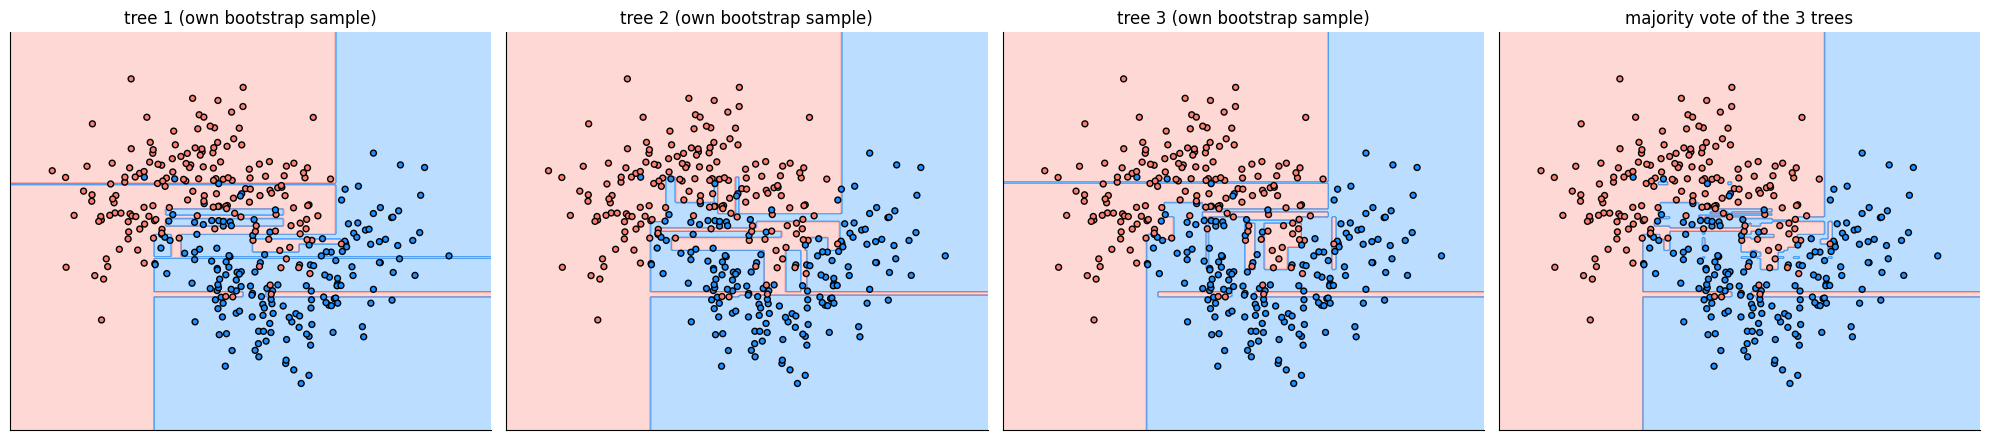

In [6]:
class Majority:                                   # tiny wrapper so plot_boundary can call .predict
    def __init__(self, models): self.models = models
    def predict(self, Z): return (np.array([m.predict(Z) for m in self.models]).sum(axis=0) >= 2).astype(int)

fig, axes = plt.subplots(1, 4, figsize=(20, 4.5))
for ax, (i, t) in zip(axes, enumerate(trees, 1)):
    plot_boundary(ax, t, X_train, y_train, f'tree {i} (own bootstrap sample)')
plot_boundary(axes[3], Majority(trees), X_train, y_train, 'majority vote of the 3 trees')
plt.tight_layout()
plt.show()

Each tree overfits its own sample in a **different** way (different islands). The vote removes many of those quirks.
With only **3** trees the vote merely ties the best tree here (0.813); the real gain comes from voting with **hundreds**
of trees, which we do next.

## 2. Why bagging works: it reduces variance

A **fully grown decision tree** has **low bias** (it fits the training data perfectly) but **high variance** (change
the data a little and the tree changes a lot). Bagging trains many such trees on different samples: each keeps its low
bias, and averaging cancels their individual over-reactions, so **variance drops**.

> Bagging helps most with **low-bias, high-variance** models: deep decision trees, sometimes KNN.
> It helps little with stable models such as linear models or SVMs (Section 5).

> 🎨 **Visualization only. You do not need to learn this code.** It just draws the picture below. Run it and focus on the plot. *(The code is collapsed; click it to expand if you are curious.)*

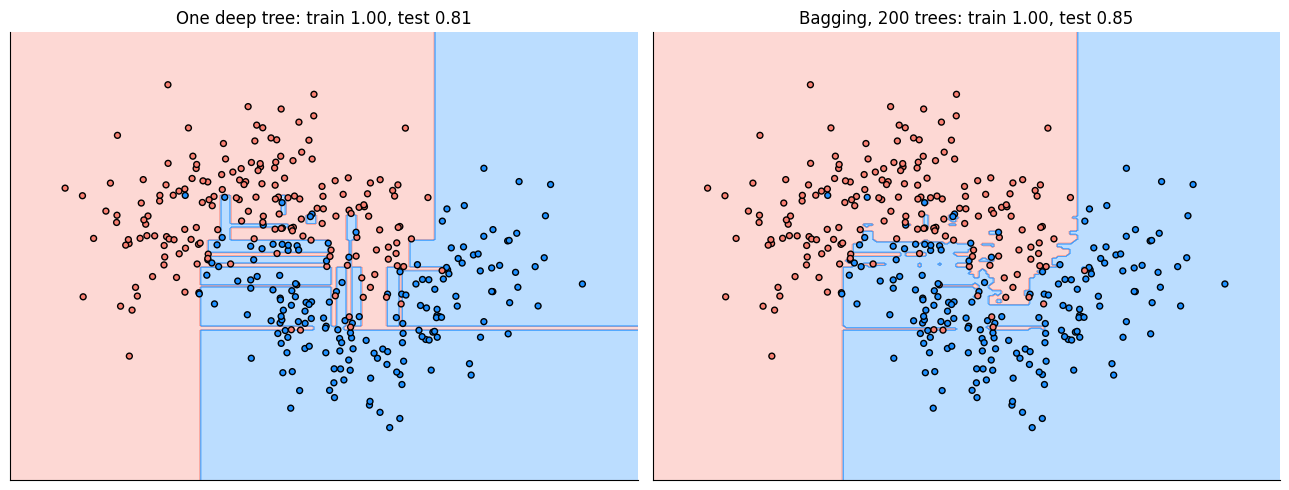

In [7]:
from sklearn.ensemble import BaggingClassifier

single = DecisionTreeClassifier(random_state=0).fit(X_train, y_train)
bag = BaggingClassifier(DecisionTreeClassifier(), n_estimators=200, random_state=0).fit(X_train, y_train)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
plot_boundary(axes[0], single, X_train, y_train,
              f'One deep tree: train {single.score(X_train, y_train):.2f}, test {single.score(X_test, y_test):.2f}')
plot_boundary(axes[1], bag, X_train, y_train,
              f'Bagging, 200 trees: train {bag.score(X_train, y_train):.2f}, test {bag.score(X_test, y_test):.2f}')
plt.tight_layout()
plt.show()

## 3. `BaggingClassifier` and its four flavours

A larger dataset: 10,000 rows, 10 features.

In [8]:
from sklearn.datasets import make_classification

X, y = make_classification(n_samples=10000, n_features=10, n_informative=3, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

tree = DecisionTreeClassifier(random_state=42).fit(X_train, y_train)
print("Single decision tree:", tree.score(X_test, y_test))

Single decision tree: 0.9265


Bagging can sample **rows**, **columns**, or both:

| Flavour | Rows (`max_samples`, `bootstrap`) | Columns (`max_features`, `bootstrap_features`) |
|---|---|---|
| **Bagging** | a fraction of rows, **with** replacement | all |
| **Pasting** | a fraction of rows, **without** replacement | all |
| **Random Subspaces** | all rows | a fraction of columns |
| **Random Patches** | a fraction of rows | a fraction of columns |

> ✍️ **Core code: learn this.** The four flavours are just different settings of `BaggingClassifier`.

In [9]:
configs = {
    'Bagging':          dict(max_samples=0.25, bootstrap=True),
    'Pasting':          dict(max_samples=0.25, bootstrap=False),
    'Random Subspaces': dict(max_samples=1.0, bootstrap=False, max_features=0.5, bootstrap_features=True),
    'Random Patches':   dict(max_samples=0.25, bootstrap=True, max_features=0.5, bootstrap_features=True),
}
for name, params in configs.items():
    model = BaggingClassifier(estimator=DecisionTreeClassifier(), n_estimators=500,
                              random_state=42, n_jobs=-1, **params)
    model.fit(X_train, y_train)
    print(f"{name:<17} test accuracy = {model.score(X_test, y_test):.4f}")

Bagging           test accuracy = 0.9450


Pasting           test accuracy = 0.9460


Random Subspaces  test accuracy = 0.9415


Random Patches    test accuracy = 0.9380


All four beat the single tree (≈ 0.927). On this dataset the differences between them are small.

**Practical tips:**
- Plain **bagging** (or pasting) is the usual default; try both.
- `max_samples` around **0.25–0.5** is a good starting point, since smaller samples make the trees more different.
  These are only starting points: always tune (end of this notebook).
- **Random subspaces / patches** are most useful with **many features** (e.g. images, text).
- `n_jobs=-1` trains the trees in parallel on all CPU cores.

### Look inside: which rows and columns did each tree get?

In [10]:
model = BaggingClassifier(DecisionTreeClassifier(), n_estimators=500, max_samples=0.25,
                          max_features=0.5, random_state=42, n_jobs=-1).fit(X_train, y_train)

print("Rows given to tree 1   :", len(model.estimators_samples_[0]), "of", len(X_train))
print("Columns given to tree 1:", sorted(model.estimators_features_[0].tolist()))

Rows given to tree 1   : 2000 of 8000
Columns given to tree 1: [3, 5, 6, 7, 8]


## 4. Out-of-bag (OOB) score: a free validation score

Each tree never saw about 37% of the training rows. Predicting every row using only the trees that did **not** see it
gives a validation score without setting aside any data.

> ✍️ **Core code: learn this.** Set `oob_score=True` and read `oob_score_`.

In [11]:
bag = BaggingClassifier(DecisionTreeClassifier(), n_estimators=500, max_samples=0.25,
                        oob_score=True, random_state=42, n_jobs=-1).fit(X_train, y_train)

print("OOB score    :", round(bag.oob_score_, 4))
print("Test accuracy:", bag.score(X_test, y_test))

OOB score    : 0.9429


Test accuracy: 0.945


The OOB estimate is close to the real test accuracy.

## 5. Which base models benefit from bagging?

In [12]:
from sklearn.svm import SVC

svc = SVC().fit(X_train, y_train)
bag_svc = BaggingClassifier(SVC(), n_estimators=50, max_samples=0.25, random_state=42, n_jobs=-1).fit(X_train, y_train)

print("Single SVC      :", svc.score(X_test, y_test))
print("Bagging of SVCs :", bag_svc.score(X_test, y_test))

Single SVC      : 0.9255


Bagging of SVCs : 0.915


Bagging SVMs made things slightly **worse** (and slower). An SVM is already a stable, low-variance model, so there is
little variance for bagging to remove, while each SVM sees only a quarter of the data. **Use bagging with high-variance
models, above all decision trees.**

### Tuning bagging

> ✍️ **Core code: learn this.** Search the key parameters with cross-validation.

In [13]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [50, 100],
    'max_samples': [0.25, 0.5, 1.0],
    'bootstrap': [True, False],
    'max_features': [0.5, 1.0],
}
search = GridSearchCV(BaggingClassifier(DecisionTreeClassifier(), random_state=42),
                      param_grid, cv=3, n_jobs=-1)
search.fit(X_train, y_train)

print("Best parameters:", search.best_params_)
print("Best CV score  :", round(search.best_score_, 4))
print("Test accuracy  :", search.score(X_test, y_test))

Best parameters: {'bootstrap': False, 'max_features': 0.5, 'max_samples': 1.0, 'n_estimators': 100}
Best CV score  : 0.9511
Test accuracy  : 0.9525


Interesting: the search chose **all rows without bootstrapping, but only half of the features per tree**,
i.e. *random subspaces*, and it beats every hand-picked setting above. Rules of thumb give you a starting point;
**tuning finds what works for your data.**

---
## Key takeaways
- **Bagging = Bootstrap + Aggregation**: same algorithm, different random samples, combined by vote / average.
- It reduces **variance**, so use it with **low-bias, high-variance** models (deep trees).
- Four flavours: **bagging** (rows with replacement), **pasting** (rows without), **random subspaces** (columns),
  **random patches** (both).
- `oob_score=True` gives a free validation estimate.
- **Random Forest** (`../04-random-forest/`) is bagging of decision trees **plus** random features at every split.

## 🧠 Quick check

<details><summary>1. What does a bootstrap sample contain?</summary>

n rows drawn with replacement: some rows repeated, about 37% of rows left out (out-of-bag).
</details>

<details><summary>2. Why does bagging help deep trees but not SVMs?</summary>

Deep trees have high variance, which averaging reduces; SVMs are already stable, so there is little variance to remove.
</details>

<details><summary>3. Bagging vs pasting?</summary>

Bagging samples rows with replacement, pasting without replacement.
</details>

➡️ **Next:** [`02-bagging-regressor.ipynb`](02-bagging-regressor.ipynb)